# Real World Classification

## Load data

Import the necessary libraries

In [1]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [2]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


## Data Preprocessing

In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # TODO: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------

    # 找出包含缺失值的欄位
    cols_with_na = [col for col in feature_cols if df[col].isnull().sum() > 0]
    
    # 3(a): 計算並顯示填補前的 Median 與 Standard Deviation
    print("=== Before Imputation ===")
    # 針對有缺失值的欄位計算中位數與標準差，並以 DataFrame 格式顯示
    stats_before = df[cols_with_na].agg(['median', 'std'])
    display(stats_before)
        
    # 使用 KNN Imputer 進行缺失值填補
    imputer = KNNImputer(n_neighbors=5)
    df[feature_cols] = imputer.fit_transform(df[feature_cols])
    
    # 3(b): 計算並顯示填補後的 Median 與 Standard Deviation
    print("=== After KNN Imputation ===")
    stats_after = df[cols_with_na].agg(['median', 'std'])
    display(stats_after)
    
    # ---------- --------------------- ----------
     
    return df, feature_cols

df, feature_cols = data_preprocessing(df)

=== Before Imputation ===


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength
median,6.300000,2.900000,5.085612,1.600000,16.300000
std,1.037115,0.389564,1.582807,0.706689,1.035228


=== After KNN Imputation ===


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength
median,6.300000,2.900000,5.035683,1.700000,16.300000
std,1.009275,0.372434,1.514955,0.694645,1.011012


In [4]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.684440,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.694645,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


## Data Exploration

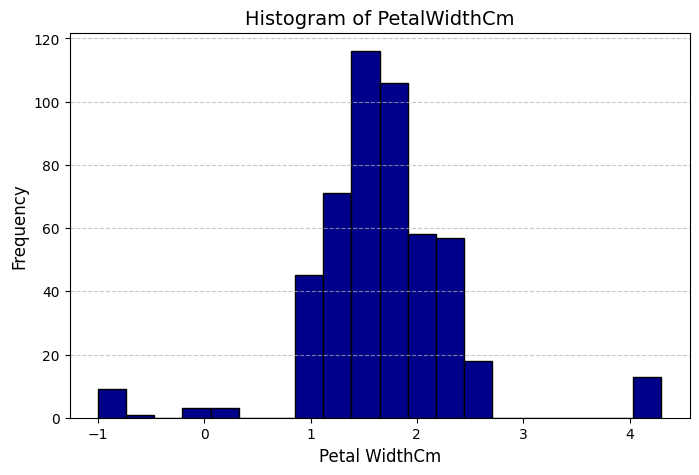

In [5]:
from sklearn.feature_selection import r_regression

# TODO: Complete the 4. Data Exploration

# 4(a): Plot the histogram of the column "PetalWidthCm"
plt.figure(figsize=(8, 5))
# 繪製直方圖，將資料分為 20 個區間
plt.hist(df['PetalWidthCm'], bins=20, color='darkblue', edgecolor='black')
plt.title('Histogram of PetalWidthCm', fontsize=14)
plt.xlabel('Petal WidthCm', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

=== Largest Positive Correlation ===
Feature: PetalWidthCompactness
Correlation: 0.991670

=== Top 5 negative correlations ===
                  feature correlation
13    SepalWidthMajorAxis   -0.096350
48        SepalGlossIndex   -0.095200
16  SepalWidthCompactness   -0.088496
18    SepalWidthCurvature   -0.081334
14    SepalWidthMinorAxis   -0.074392


C:\Users\lee\AppData\Local\Temp\ipykernel_17980\3401339101.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(df[features_to_plot].values,


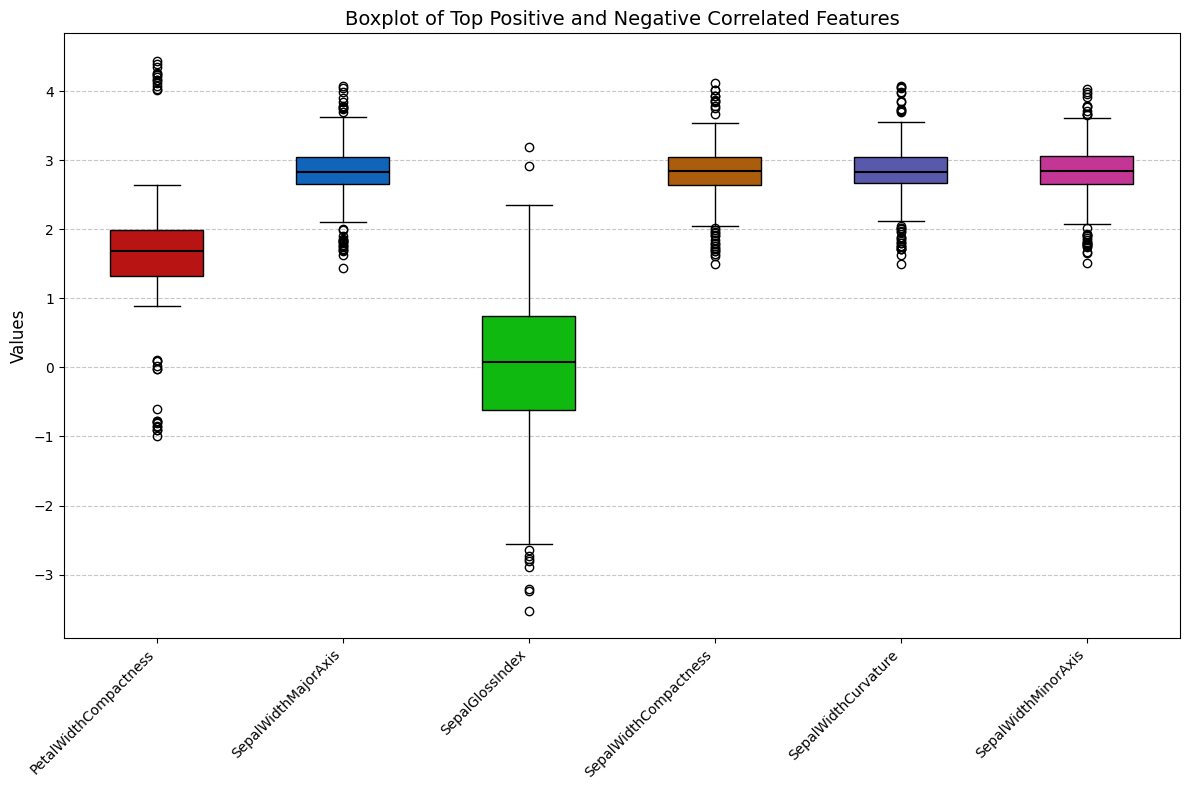

In [6]:
from sklearn.feature_selection import r_regression
import pandas as pd

# 排除不需要計算的欄位 (PetalWidthCm, Species, Id)
features_to_check = [col for col in feature_cols if col not in ['PetalWidthCm', 'Species', 'Id']]

# 提取 X (特徵矩陣) 和 y (目標變數 PetalWidthCm)
X = df[features_to_check].values
y = df['PetalWidthCm'].values

# 使用 r_regression 計算 Pearson correlation
correlations = r_regression(X, y)

# 將結果轉換為 Pandas Series 方便排序
corr_series = pd.Series(correlations, index=features_to_check)

# 4(b): 找出最大正相關的特徵
largest_pos_feature = corr_series.idxmax()
largest_pos_value = corr_series.max()

print("=== Largest Positive Correlation ===")
print(f"Feature: {largest_pos_feature}")
print(f"Correlation: {largest_pos_value:.6f}\n")

# 4(c): 找出前五大最強負相關的特徵
top_5_neg_features = corr_series.sort_values(ascending=True).head(5)

print("=== Top 5 negative correlations ===")
# 取得這些特徵在原始 DataFrame 中的欄位位置 
original_indices = [df.columns.get_loc(feat) for feat in top_5_neg_features.index]

df_neg = pd.DataFrame({
    'feature': top_5_neg_features.index,
    'correlation': top_5_neg_features.apply(lambda x: f"{x:.6f}").values
}, index=original_indices)

print(df_neg)

# ---------- 4(d): Boxplot ----------

# 將 4(b) 和 4(c) 找到的特徵合併成一個 List
features_to_plot = [largest_pos_feature] + list(top_5_neg_features.index)

plt.figure(figsize=(12, 8))

bplot = plt.boxplot(df[features_to_plot].values, 
                    patch_artist=True, 
                    labels=features_to_plot,
                    medianprops=dict(color='black', linewidth=1.5))

colors = ["#B81414", "#1065ba", "#0fb90f", "#ab5c0d", "#5858ac", "#c43695"]

for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Boxplot of Top Positive and Negative Correlated Features', fontsize=14)
plt.ylabel('Values', fontsize=12)
plt.xticks(rotation=45, ha='right') # 旋轉 X 軸標籤以免重疊
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Model Training

### Prepare the data

In [7]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
        
X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### Q1(a)：5-fold Cross-Validation

In [8]:
from sklearn.model_selection import KFold, cross_val_score
import pandas as pd
import numpy as np

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Hyperparameter settings required by Q1(a)
learning_rates = [0.005, 0.01, 0.1, 0.5]
reg_lambdas = [1.0, 2.0, 4.0, 8.0]

# 5-fold CV setting required by the assignment
cv = KFold(n_splits=5, shuffle=True, random_state=40)

cv_results = []

for lr in learning_rates:
    for reg_lambda in reg_lambdas:
        model = LinearModel(
            dim=X_train.shape[1],
            is_reg=False,
            loss_fn=loss_fn,
            act_fn=act_fn,
            grad_fn=grad_fn,
            lr=lr,
            reg_type='l2',
            reg_lambda=reg_lambda,
            n_iteration=10000,
            random_state=seed,
            verbose=False,
            plot_curve=False
        )
        
        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring='accuracy'
        )
        
        cv_results.append({
            "learning_rate": lr,
            "reg_lambda": reg_lambda,
            "fold_1": scores[0],
            "fold_2": scores[1],
            "fold_3": scores[2],
            "fold_4": scores[3],
            "fold_5": scores[4],
            "avg_accuracy": scores.mean()
        })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,learning_rate,reg_lambda,fold_1,fold_2,fold_3,fold_4,fold_5,avg_accuracy
0,0.005,1.0,0.700000,0.757143,0.728571,0.642857,0.757143,0.717143
1,0.005,2.0,0.700000,0.757143,0.714286,0.642857,0.785714,0.720000
2,0.005,4.0,0.728571,0.742857,0.714286,0.671429,0.771429,0.725714
3,0.005,8.0,0.742857,0.728571,0.700000,0.700000,0.742857,0.722857
4,0.010,1.0,0.700000,0.785714,0.728571,0.614286,0.785714,0.722857
5,0.010,2.0,0.714286,0.785714,0.728571,0.628571,0.785714,0.728571
6,0.010,4.0,0.742857,0.757143,0.700000,0.657143,0.771429,0.725714
7,0.010,8.0,0.742857,0.728571,0.685714,0.700000,0.728571,0.717143
8,0.100,1.0,0.714286,0.742857,0.714286,0.671429,0.771429,0.722857
9,0.100,2.0,0.728571,0.771429,0.700000,0.642857,0.785714,0.725714


### results in a 4×4 table

In [9]:
cv_table = cv_results_df.pivot(
    index="reg_lambda",
    columns="learning_rate",
    values="avg_accuracy"
)
print("Average accuracy over 5 folds:")
cv_table

Average accuracy over 5 folds:


learning_rate,0.005,0.010,0.100,0.500
reg_lambda,,,,
1.0,0.717143,0.722857,0.722857,0.722857
2.0,0.720000,0.728571,0.725714,0.691429
4.0,0.725714,0.725714,0.725714,0.534286
8.0,0.722857,0.717143,0.717143,0.465714


In [10]:
top2_params = cv_results_df.sort_values(
    by="avg_accuracy",
    ascending=False
).head(2)

top2_params

,learning_rate,reg_lambda,fold_1,fold_2,fold_3,fold_4,fold_5,avg_accuracy
5,0.010,2.0,0.714286,0.785714,0.728571,0.628571,0.785714,0.728571
2,0.005,4.0,0.728571,0.742857,0.714286,0.671429,0.771429,0.725714


Testing result for lr=0.01, reg_lambda=2.0
Model Evaluation
Accuracy  : 0.7600
Precision : 0.7381
Recall    : 0.8158
F1-score  : 0.7750


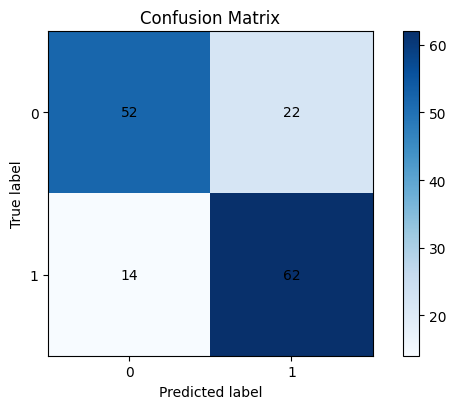

Testing result for lr=0.005, reg_lambda=4.0
Model Evaluation
Accuracy  : 0.7533
Precision : 0.7241
Recall    : 0.8289
F1-score  : 0.7730


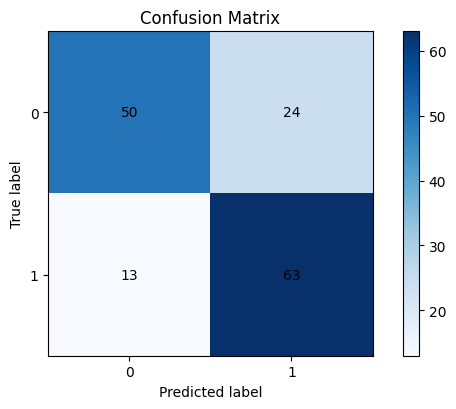

In [11]:
from model.metrics import evaluate_binary_classifier

test_results = []

for idx, row in top2_params.iterrows():
    lr = row["learning_rate"]
    reg_lambda = row["reg_lambda"]
    
    print("=" * 60)
    print(f"Testing result for lr={lr}, reg_lambda={reg_lambda}")
    print("=" * 60)
    
    final_model = LinearModel(
        dim=X_train.shape[1],
        is_reg=False,
        loss_fn=loss_fn,
        act_fn=act_fn,
        grad_fn=grad_fn,
        lr=lr,
        reg_type='l2',
        reg_lambda=reg_lambda,
        n_iteration=10000,
        random_state=seed,
        verbose=False,
        plot_curve=False
    )
    
    final_model.fit(X_train, y_train)
    y_pred = final_model.predict(X_test)
    
    evaluate_binary_classifier(y_test, y_pred)

### Train the model!

50. Training loss: 0.6737565170340649, Val loss:0.6828695995569816
100. Training loss: 0.6747289430162428, Val loss:0.6839071965242837
150. Training loss: 0.6747483271618208, Val loss:0.6839293732638189
200. Training loss: 0.6747487102403308, Val loss:0.6839298451300981
250. Training loss: 0.674748717829201, Val loss:0.6839298552460086
300. Training loss: 0.6747487179798805, Val loss:0.6839298554645057
350. Training loss: 0.6747487179828774, Val loss:0.6839298554692588
400. Training loss: 0.674748717982937, Val loss:0.6839298554693629
450. Training loss: 0.6747487179829381, Val loss:0.683929855469365
500. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
550. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
600. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
650. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
700. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
750. Training loss: 0.6747487179829382, Val loss:0.6

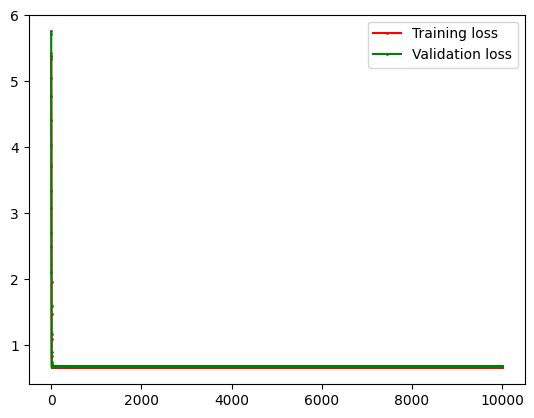

Model parameters (weights): [[-0.01249206]
 [ 0.02228109]
 [ 0.00731174]
 [ 0.02160094]
 [ 0.03647292]
 [ 0.01868654]
 [ 0.01769178]
 [ 0.01789019]
 [ 0.01923883]
 [ 0.02027882]
 [ 0.01914643]
 [ 0.02013799]
 [ 0.02095232]
 [ 0.00458568]
 [ 0.00311998]
 [ 0.00605684]
 [ 0.00705284]
 [ 0.00742952]
 [ 0.00627274]
 [ 0.02328098]
 [ 0.02385686]
 [ 0.02565637]
 [ 0.02391417]
 [ 0.02520387]
 [ 0.02375411]
 [ 0.03462815]
 [ 0.03522777]
 [ 0.03662822]
 [ 0.03649798]
 [ 0.036714  ]
 [ 0.03671077]
 [-0.01304758]
 [ 0.00456383]
 [-0.00644573]
 [-0.00238571]
 [-0.00519696]
 [-0.00335385]
 [-0.0124363 ]
 [-0.02754184]
 [-0.00523545]
 [-0.00983527]
 [-0.0041134 ]
 [-0.01539004]
 [-0.00700335]
 [-0.0017571 ]
 [-0.00552268]
 [-0.00863107]
 [-0.00523874]
 [-0.01145154]
 [-0.00881981]
 [-0.00133932]
 [-0.00757033]
 [-0.00632656]
 [-0.0080036 ]
 [-0.00210421]
 [-0.00160616]
 [-0.00839356]
 [-0.01317914]
 [-0.00861225]
 [-0.01061584]
 [-0.01525315]
 [-0.00042755]
 [ 0.00442472]
 [-0.01255564]
 [-0.0094437

In [50]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)
model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
model.fit(X_train, y_train,lr=0.1, n_iteration =10000,val_ratio=0.2, reg_type='l2', reg_lambda=100)

# print model parameters
print("Model parameters (weights):", model.W)
# sum of absolute values of weights
print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

## Metrics

Model Evaluation
Accuracy  : 0.5067
Precision : 0.5067
Recall    : 1.0000
F1-score  : 0.6726


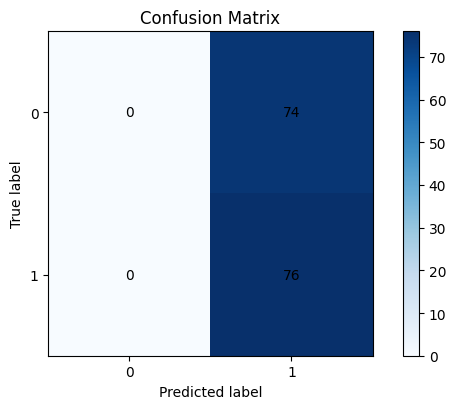

{'Accuracy': 0.5066666666666667,
 'Precision': 0.5066666666666667,
 'Recall': 1.0,
 'F1-score': 0.672566371681416}

In [51]:
# use evaluate_binary_classifier to evaluate the model on the test set
from model.metrics import evaluate_binary_classifier

y_pred = model.predict(X_test)
evaluate_binary_classifier(y_test, y_pred)